In [ ]:
import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, mixed_precision
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score
)

warnings.filterwarnings("ignore")

# ---- Reproducibility (critical for research papers) ----
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Mixed precision for T4 speedup ----
mixed_precision.set_global_policy("mixed_float16")
tf.keras.backend.clear_session()

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Precision policy:", mixed_precision.global_policy().name)

2026-03-20 17:37:52.092671: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774028272.299386      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774028272.355502      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774028272.869715      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774028272.869782      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774028272.869784      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Precision policy: float32


In [ ]:

#Hyperparameters (all in one place for ablation study)

CFG = {
    # ── Paths ──────────────────────────────────────────────────
    "base"          : "/kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset",
    "out_dir"       : "/kaggle/working",

    # ── Image ──────────────────────────────────────────────────
    "img_size"      : (224, 224),
    "channels"      : 3,

    # ── Training ───────────────────────────────────────────────
    "batch_size"    : 32,
    "lr_stage1"     : 2e-4,      # frozen backbone
    "lr_stage2"     : 5e-5,      # fine-tune top layers
    "epochs_s1"     : 6,
    "epochs_s2"     : 10,
    "patience_stop" : 5,
    "patience_lr"   : 3,
    "label_smooth"  : 0.05,      # reduces overconfidence

    # ── Architecture ───────────────────────────────────────────
    "unfreeze_n"    : 40,        # top-N layers to unfreeze in stage 2
    "dense_units"   : 512,
    "dropout1"      : 0.5,
    "dropout2"      : 0.3,
    "attn_heads"    : 4,         # multi-head self-attention
    "attn_key_dim"  : 64,

    # ── Augmentation ───────────────────────────────────────────
    "rot"           : 15,
    "zoom"          : 0.15,
    "shift"         : 0.10,
    "brightness"    : [0.85, 1.15],
    "shear"         : 0.08,
}

TRAIN_PATH = os.path.join(CFG["base"], "Train")
VAL_PATH   = os.path.join(CFG["base"], "Validation")
TEST_PATH  = os.path.join(CFG["base"], "Test")

for split, path in [("Train", TRAIN_PATH), ("Val", VAL_PATH), ("Test", TEST_PATH)]:
    exists = os.path.exists(path)
    if not exists:
        raise FileNotFoundError(f"{split} path not found: {path}")
    print(f"[OK] {split}: {path}")

[OK] Train: /kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Train
[OK] Val: /kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Validation
[OK] Test: /kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset/Test


In [ ]:

#Data Generators
train_datagen = ImageDataGenerator(
    rotation_range      = CFG["rot"],
    zoom_range          = CFG["zoom"],
    width_shift_range   = CFG["shift"],
    height_shift_range  = CFG["shift"],
    shear_range         = CFG["shear"],
    brightness_range    = CFG["brightness"],
    horizontal_flip     = True,
    fill_mode           = "reflect",         # edge pixels ≈ real face
)

base_datagen = ImageDataGenerator()

def make_gen(datagen, path, shuffle=True):
    return datagen.flow_from_directory(
        path,
        target_size  = CFG["img_size"],
        batch_size   = CFG["batch_size"],
        class_mode   = "binary",
        shuffle      = shuffle,
        seed         = SEED,
    )

train_gen = make_gen(train_datagen, TRAIN_PATH, shuffle=True)
val_gen   = make_gen(base_datagen,  VAL_PATH,   shuffle=False)
test_gen  = make_gen(base_datagen,  TEST_PATH,  shuffle=False)

# Class index mapping (important for correct label interpretation)
IDX2CLS = {v: k for k, v in train_gen.class_indices.items()}
print("\nClass mapping:", train_gen.class_indices)
print(f"Train  : {train_gen.samples:,} samples")
print(f"Val    : {val_gen.samples:,} samples")
print(f"Test   : {test_gen.samples:,} samples")

# ---- Compute class weights for imbalanced datasets ----
n_total = train_gen.samples
n_fake  = int(train_gen.classes.sum())
n_real  = n_total - n_fake
w_real  = n_total / (2.0 * n_real)
w_fake  = n_total / (2.0 * n_fake)
class_weight = {0: w_real, 1: w_fake}
print(f"\nClass weights — Real: {w_real:.3f} | Fake: {w_fake:.3f}")

Found 140002 images belonging to 2 classes.
Found 39428 images belonging to 2 classes.
Found 10905 images belonging to 2 classes.

Class mapping: {'Fake': 0, 'Real': 1}
Train  : 140,002 samples
Val    : 39,428 samples
Test   : 10,905 samples

Class weights — Real: 1.000 | Fake: 1.000


In [ ]:

#Novel Architecture: EfficientNetB4 + Self-Attention Head(Hybrid CNN)


class SelfAttentionBlock(layers.Layer):
    """
    Lightweight multi-head self-attention applied to spatial CNN features.
    Reshapes (H, W, C) → (H*W, C) sequence, attends, then reshapes back.
    """
    def __init__(self, num_heads, key_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim   = key_dim
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=key_dim, dropout=0.1
        )
        self.norm = layers.LayerNormalization()
        self.proj = layers.Dense(key_dim * num_heads)   # project to fixed dim

    def call(self, x, training=False):
        # x: (B, H, W, C)
        B = tf.shape(x)[0]
        H, W, C = x.shape[1], x.shape[2], x.shape[3]
        seq = tf.reshape(x, (B, H * W, C))          # (B, HW, C)
        seq = self.proj(seq)                          # (B, HW, d_model)
        attn_out = self.attn(seq, seq, training=training)
        out = self.norm(seq + attn_out)               # residual
        return out  # (B, HW, d_model)  — pooled downstream

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_heads": self.num_heads, "key_dim": self.key_dim})
        return cfg


def build_research_model(lr: float = CFG["lr_stage1"]):
    """
    Hybrid CNN + Self-Attention deepfake detector.

    Architecture:
        Input (224×224×3)
        → EfficientNetB4 backbone (frozen, ImageNet weights)
        → Feature map (7×7×1792)
        → SelfAttentionBlock (multi-head, 4 heads × 64 dim)
        → Global Average Pooling  +  GlobalMaxPooling (dual pool)
        → Concatenate  →  BN  →  Dense(512, ReLU)  →  Dropout
        → Dense(256, ReLU)  →  Dropout
        → Dense(1, sigmoid, float32)
    """
    backbone = EfficientNetB4(
        include_top  = False,
        weights      = "imagenet",
        input_shape  = (*CFG["img_size"], CFG["channels"]),
    )
    backbone.trainable = False

    inputs = keras.Input(shape=(*CFG["img_size"], CFG["channels"]), name="image_input")

    # ── Backbone ──
    x = keras.applications.efficientnet.preprocess_input(inputs)
    x = backbone(x, training=False)                 # (B, 7, 7, 1792)

    # ── Dual Spatial Pooling ──
    avg_pool = layers.GlobalAveragePooling2D()(x)   # (B, 1792)
    max_pool = layers.GlobalMaxPooling2D()(x)        # (B, 1792)

    # ── Self-Attention over spatial features ──
    attn_out = SelfAttentionBlock(
        num_heads = CFG["attn_heads"],
        key_dim   = CFG["attn_key_dim"],
        name      = "self_attention"
    )(x, training=False)                             # (B, 49, 256)
    attn_pool = layers.GlobalAveragePooling1D()(attn_out)  # (B, 256)

    # ── Feature Fusion ──
    fused = layers.Concatenate(name="feature_fusion")([avg_pool, max_pool, attn_pool])
    fused = layers.BatchNormalization()(fused)
    fused = layers.Dropout(CFG["dropout1"])(fused)

    # ── Classification Head ──
    x = layers.Dense(CFG["dense_units"], activation="relu", name="dense_1")(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(CFG["dropout2"])(x)
    x = layers.Dense(256, activation="relu", name="dense_2")(x)
    x = layers.Dropout(0.2)(x)

    # float32 output for numerical stability with mixed precision
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32", name="output")(x)

    model = keras.Model(inputs, outputs, name="DeepfakeDetector_EfficientB4_Attn")

    # ── Label Smoothing Loss ──
    loss_fn = keras.losses.BinaryCrossentropy(label_smoothing=CFG["label_smooth"])

    model.compile(
        optimizer = keras.optimizers.Adam(lr, clipnorm=1.0),
        loss      = loss_fn,
        metrics   = [
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(name="pr_auc", curve="PR"),  # Precision-Recall AUC
        ],
    )
    return model, backbone


model, backbone = build_research_model()
model.summary()

# ---- Parameter count for paper ----
total_params = model.count_params()
trainable    = sum(np.prod(v.shape) for v in model.trainable_weights)
print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable (Stage 1) : {trainable:,}")

I0000 00:00:1774028465.280862      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774028465.286806      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DeepfakeDetector_EfficientB4_Attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb4      │ (None, 7, 7,      │ 17,673,823 │ image_input[0][0] │
│ (Functional)        │ 1792)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 49, 256)   │    722,688 │ efficientnetb4[0… │
│ (SelfAttentionBloc… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1792)      │          0 │ efficientnetb4[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1792)      │          0 │ efficientnetb4[0… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ self_attention[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 3840)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 3840)      │     15,360 │ feature_fusion[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 3840)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 512)       │  1,966,592 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,512,096 (78.25 MB)

 Trainable params: 2,829,569 (10.79 MB)

 Non-trainable params: 17,682,527 (67.45 MB)


Total parameters    : 20,512,096
Trainable (Stage 1) : 2,829,569


In [ ]:

# CELL 5 — Callbacks

def get_callbacks(stage: str):
    ckpt = os.path.join(CFG["out_dir"], f"best_{stage}.keras")
    return [
        EarlyStopping(
            monitor            = "val_auc",
            patience           = CFG["patience_stop"],
            mode               = "max",
            restore_best_weights = True,
            verbose            = 1,
        ),
        ReduceLROnPlateau(
            monitor  = "val_loss",
            factor   = 0.5,
            patience = CFG["patience_lr"],
            min_lr   = 1e-8,
            verbose  = 1,
        ),
        ModelCheckpoint(
            ckpt,
            monitor   = "val_auc",
            mode      = "max",
            save_best_only = True,
            verbose   = 1,
        ),
        CSVLogger(
            os.path.join(CFG["out_dir"], f"log_{stage}.csv"),
            separator = ",",
            append    = False,
        ),
    ]

In [ ]:

# CELL 6 — Stage 1: Train Head Only (frozen backbone)

print("\n" + "="*60)
print("  STAGE 1 — Training classification head")
print("="*60)

history_s1 = model.fit(
    train_gen,
    epochs          = CFG["epochs_s1"],
    validation_data = val_gen,
    callbacks       = get_callbacks("stage1"),
    class_weight    = class_weight,
    verbose         = 1,
)


  STAGE 1 — Training classification head
Epoch 1/6


I0000 00:00:1774028496.259092     144 service.cc:152] XLA service 0x7b8854026040 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774028496.259128     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774028496.259134     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774028502.099583     144 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-20 17:41:54.022562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 17:41:54.161135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 17:41:54.411074: E external/local_xl

1098/4376 ━━━━━━━━━━━━━━━━━━━━ 39:53 730ms/step - accuracy: 0.6876 - auc: 0.7554 - loss: 0.6385 - pr_auc: 0.7344 - precision: 0.6875 - recall: 0.6738

2026-03-20 17:55:51.746249: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 17:55:51.879672: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 17:55:52.112367: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 17:55:52.246688: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 17:55:52.480334: E external/local_xla/xla/stream_

4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.7602 - auc: 0.8378 - loss: 0.5331 - pr_auc: 0.8244 - precision: 0.7562 - recall: 0.7625

2026-03-20 18:38:43.381427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 18:38:43.514862: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 18:38:43.745262: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 18:38:43.880303: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 18:38:44.116929: E external/local_xla/xla/stream_


Epoch 1: val_auc improved from -inf to 0.92333, saving model to /kaggle/working/best_stage1.keras
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 3463s 777ms/step - accuracy: 0.7602 - auc: 0.8378 - loss: 0.5331 - pr_auc: 0.8244 - precision: 0.7562 - recall: 0.7625 - val_accuracy: 0.8204 - val_auc: 0.9233 - val_loss: 0.4370 - val_pr_auc: 0.9222 - val_precision: 0.9054 - val_recall: 0.7170 - learning_rate: 2.0000e-04
Epoch 2/6
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.8489 - auc: 0.9250 - loss: 0.3940 - pr_auc: 0.9192 - precision: 0.8431 - recall: 0.8570
Epoch 2: val_auc improved from 0.92333 to 0.92548, saving model to /kaggle/working/best_stage1.keras
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 2221s 507ms/step - accuracy: 0.8489 - auc: 0.9250 - loss: 0.3940 - pr_auc: 0.9192 - precision: 0.8431 - recall: 0.8570 - val_accuracy: 0.7792 - val_auc: 0.9255 - val_loss: 0.5194 - val_pr_auc: 0.9244 - val_precision: 0.9381 - val_recall: 0.5996 - learning_rate: 2.0000e-04
Epoch 3/6
4376/4376 ━━━━━━━━━━━━━━━

In [ ]:
model.save(os.path.join(CFG["out_dir"], "stage1_weights_backup.keras"))
print("Stage 1 backup saved")

Stage 1 backup saved


In [ ]:
#Fine-tune Top Layers (gradual unfreezing)


print("\n" + "="*60)
print(f"  STAGE 2 — Fine-tuning top {CFG['unfreeze_n']} backbone layers")
print("="*60)

backbone.trainable = True
for layer in backbone.layers[: -CFG["unfreeze_n"]]:
    layer.trainable = False

# Use lower LR + clipnorm to prevent catastrophic forgetting
loss_fn = keras.losses.BinaryCrossentropy(label_smoothing=CFG["label_smooth"])
model.compile(
    optimizer = keras.optimizers.Adam(CFG["lr_stage2"], clipnorm=1.0),
    loss      = loss_fn,
    metrics   = [
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

trainable_s2 = sum(np.prod(v.shape) for v in model.trainable_weights)
print(f"Trainable params (Stage 2): {trainable_s2:,}")

total_epochs = CFG["epochs_s1"] + CFG["epochs_s2"]

history_s2 = model.fit(
    train_gen,
    epochs          = total_epochs,
    initial_epoch   = CFG["epochs_s1"],
    validation_data = val_gen,
    callbacks       = get_callbacks("stage2"),
    class_weight    = class_weight,
    verbose         = 1,
)

# Save final model
final_path = os.path.join(CFG["out_dir"], "deepfake_efficientb4_attn_final.keras")
model.save(final_path)
print(f"\nFinal model saved → {final_path}")


  STAGE 2 — Fine-tuning top 40 backbone layers
Trainable params (Stage 2): 8,774,073
Epoch 7/16
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.8714 - auc: 0.9405 - loss: 0.3573 - pr_auc: 0.9366
Epoch 7: val_auc improved from -inf to 0.97466, saving model to /kaggle/working/best_stage2.keras
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 2331s 517ms/step - accuracy: 0.8714 - auc: 0.9405 - loss: 0.3573 - pr_auc: 0.9366 - val_accuracy: 0.9087 - val_auc: 0.9747 - val_loss: 0.2912 - val_pr_auc: 0.9755 - learning_rate: 5.0000e-05
Epoch 8/16
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.9322 - auc: 0.9811 - loss: 0.2496 - pr_auc: 0.9803
Epoch 8: val_auc improved from 0.97466 to 0.98012, saving model to /kaggle/working/best_stage2.keras
4376/4376 ━━━━━━━━━━━━━━━━━━━━ 2298s 525ms/step - accuracy: 0.9322 - auc: 0.9811 - loss: 0.2496 - pr_auc: 0.9803 - val_accuracy: 0.9206 - val_auc: 0.9801 - val_loss: 0.2720 - val_pr_auc: 0.9808 - learning_rate: 5.0000e-05
Epoch 9/16
4376/4376 ━━━━━━━━

In [ ]:

#Load Best Checkpoint & Test EvaluationB

best_model = keras.models.load_model(
    os.path.join(CFG["out_dir"], "best_stage2.keras"),
    custom_objects={"SelfAttentionBlock": SelfAttentionBlock},
)

print("\n" + "="*60)
print("  TEST SET EVALUATION")
print("="*60)

test_gen.reset()
results = best_model.evaluate(test_gen, verbose=1)
print("\nTest Results:")
for name, val in zip(best_model.metrics_names, results):
    print(f"  {name:10s}: {val:.4f}")


  TEST SET EVALUATION
340/341 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.9208 - auc: 0.4696 - loss: 0.2825 - pr_auc: 0.4427

2026-03-21 03:59:41.975243: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 03:59:42.111361: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 03:59:42.360247: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 03:59:42.502678: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 03:59:42.786244: E external/local_xla/xla/stream_

341/341 ━━━━━━━━━━━━━━━━━━━━ 141s 367ms/step - accuracy: 0.9204 - auc: 0.4722 - loss: 0.2836 - pr_auc: 0.4456

Test Results:
  loss      : 0.4678
  compile_metrics: 0.8422


In [ ]:
#  Full Metrics Suite

test_gen.reset()
y_prob  = best_model.predict(test_gen, verbose=1).ravel()
y_true  = test_gen.classes
y_pred  = (y_prob > 0.5).astype(int)

# Core metrics
acc   = accuracy_score(y_true, y_pred)
prec  = precision_score(y_true, y_pred)
rec   = recall_score(y_true, y_pred)
f1    = f1_score(y_true, y_pred)
auc   = roc_auc_score(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)
spec  = recall_score(y_true, y_pred, pos_label=0)   # specificity = recall for "real"

print("\n" + "="*60)
print("  RESEARCH METRICS  ")
print("="*60)
print(f"  Accuracy    : {acc*100:.2f}%")
print(f"  Precision   : {prec*100:.2f}%")
print(f"  Recall/Sens : {rec*100:.2f}%")
print(f"  Specificity : {spec*100:.2f}%")
print(f"  F1 Score    : {f1*100:.2f}%")
print(f"  ROC-AUC     : {auc:.4f}")
print(f"  PR-AUC      : {pr_auc:.4f}")

print("\nPer-Class Classification Report:")
target_names = [IDX2CLS[0], IDX2CLS[1]]
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))


341/341 ━━━━━━━━━━━━━━━━━━━━ 57s 133ms/step

  RESEARCH METRICS  
  Accuracy    : 84.22%
  Precision   : 92.69%
  Recall/Sens : 74.04%
  Specificity : 94.25%
  F1 Score    : 82.33%
  ROC-AUC     : 0.9253
  PR-AUC      : 0.9367

Per-Class Classification Report:
              precision    recall  f1-score   support

        Fake     0.7865    0.9425    0.8575      5492
        Real     0.9269    0.7404    0.8233      5413

    accuracy                         0.8422     10905
   macro avg     0.8567    0.8415    0.8404     10905
weighted avg     0.8562    0.8422    0.8405     10905



In [ ]:
# Optimal Threshold via Youden's

fpr_arr, tpr_arr, thresholds = roc_curve(y_true, y_prob)
youdens_j     = tpr_arr - fpr_arr
opt_idx       = np.argmax(youdens_j)
opt_threshold = thresholds[opt_idx]
y_pred_opt    = (y_prob > opt_threshold).astype(int)

print(f"\nOptimal threshold (Youden's J): {opt_threshold:.4f}")
print(f"  F1 @ optimal  : {f1_score(y_true, y_pred_opt)*100:.2f}%")
print(f"  Acc @ optimal : {accuracy_score(y_true, y_pred_opt)*100:.2f}%")


Optimal threshold (Youden's J): 0.1296
  F1 @ optimal  : 86.68%
  Acc @ optimal : 86.82%


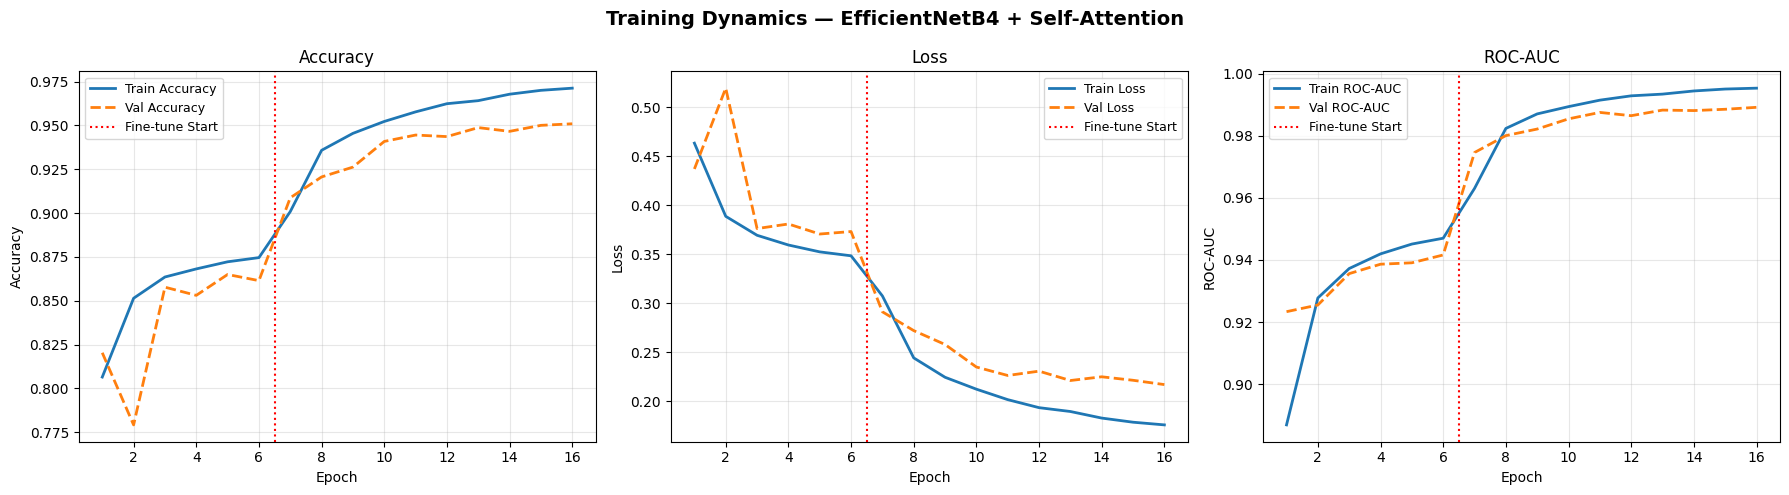

Saved: fig_training_curves.png


In [ ]:
#Training Curves---

def merge_histories(h1, h2, key):
    """Concatenate metric across two training stages."""
    return h1.history.get(key, []) + h2.history.get(key, [])

stage_boundary = CFG["epochs_s1"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training Dynamics — EfficientNetB4 + Self-Attention", fontsize=14, fontweight="bold")

plots = [
    ("Accuracy",  "accuracy",  "val_accuracy"),
    ("Loss",      "loss",      "val_loss"),
    ("ROC-AUC",   "auc",       "val_auc"),
]

for ax, (title, tr_key, vl_key) in zip(axes, plots):
    tr = merge_histories(history_s1, history_s2, tr_key)
    vl = merge_histories(history_s1, history_s2, vl_key)
    eps = range(1, len(tr) + 1)

    ax.plot(eps, tr, label=f"Train {title}", lw=2)
    ax.plot(eps, vl, label=f"Val {title}",   lw=2, linestyle="--")
    ax.axvline(stage_boundary + 0.5, color="red", linestyle=":", lw=1.5, label="Fine-tune Start")
    ax.set(xlabel="Epoch", ylabel=title, title=title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG["out_dir"], "fig_training_curves.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig_training_curves.png")

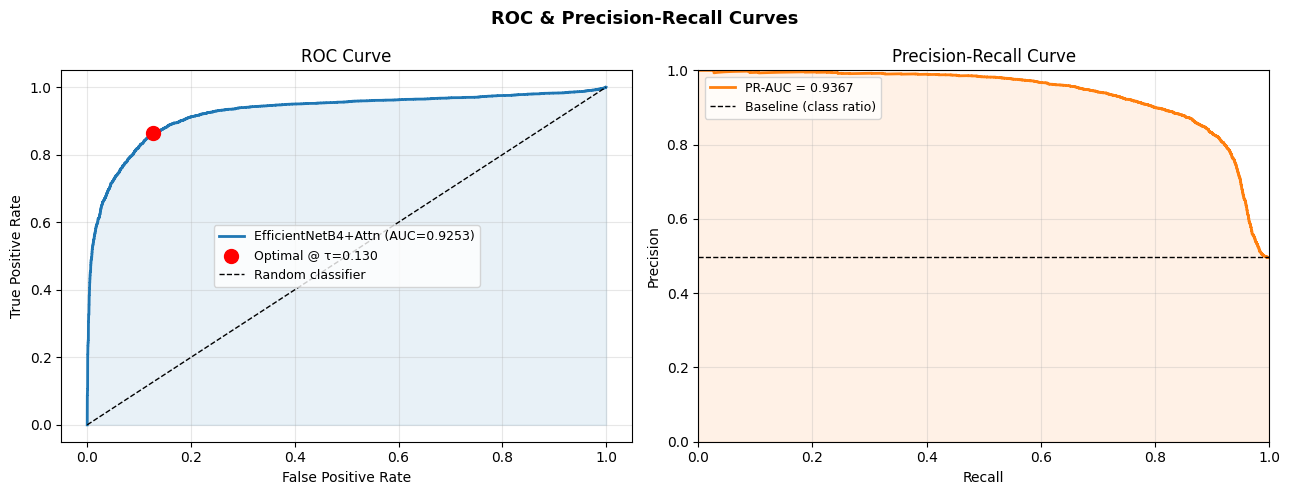

Saved: fig_roc_pr.png


In [ ]:
#ROC + Precision-Recall Curves

prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("ROC & Precision-Recall Curves", fontsize=13, fontweight="bold")

# ROC
ax = axes[0]
ax.plot(fpr_arr, tpr_arr, lw=2, color="#1f77b4",
        label=f"EfficientNetB4+Attn (AUC={auc:.4f})")
ax.scatter(fpr_arr[opt_idx], tpr_arr[opt_idx], s=100, color="red", zorder=5,
           label=f"Optimal @ τ={opt_threshold:.3f}")
ax.fill_between(fpr_arr, tpr_arr, alpha=0.1, color="#1f77b4")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Precision-Recall
ax = axes[1]
ax.plot(rec_curve, prec_curve, lw=2, color="#ff7f0e",
        label=f"PR-AUC = {pr_auc:.4f}")
ax.fill_between(rec_curve, prec_curve, alpha=0.1, color="#ff7f0e")
ax.axhline(y=y_true.mean(), color="k", linestyle="--", lw=1, label="Baseline (class ratio)")
ax.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve", xlim=[0, 1], ylim=[0, 1])
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG["out_dir"], "fig_roc_pr.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig_roc_pr.png")


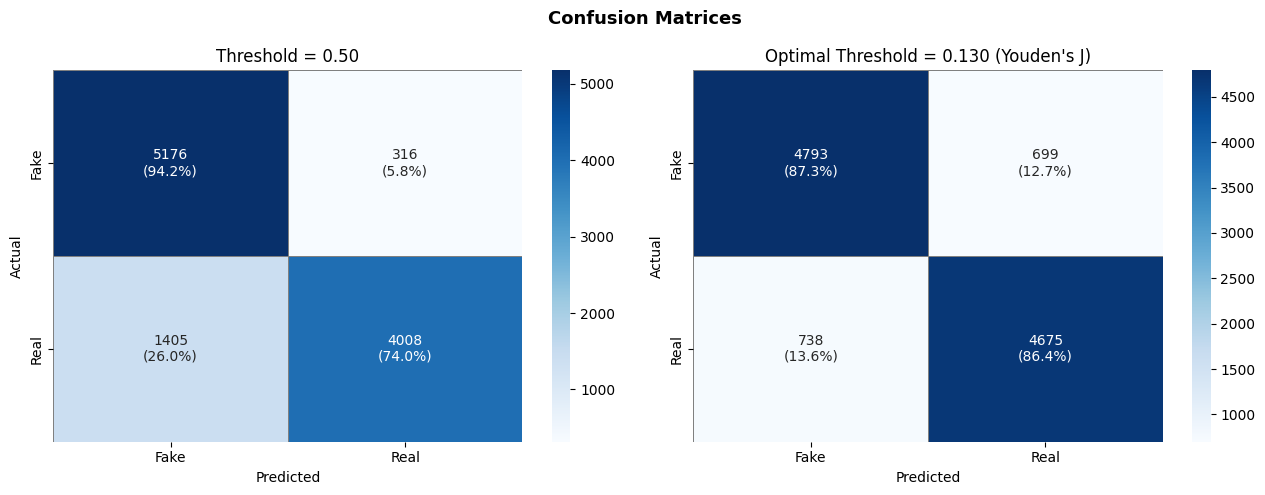

Saved: fig_confusion_matrices.png


In [ ]:
#Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrices", fontsize=13, fontweight="bold")

cls_labels = [IDX2CLS[0], IDX2CLS[1]]

for ax, preds, title in zip(
    axes,
    [y_pred, y_pred_opt],
    [f"Threshold = 0.50", f"Optimal Threshold = {opt_threshold:.3f} (Youden's J)"],
):
    cm      = confusion_matrix(y_true, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    annot   = np.array([[f"{v}\n({cm_norm[i,j]:.1%})"
                          for j, v in enumerate(row)]
                          for i, row in enumerate(cm)])
    sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", ax=ax,
                xticklabels=cls_labels, yticklabels=cls_labels,
                linewidths=0.5, linecolor="gray")
    ax.set(xlabel="Predicted", ylabel="Actual", title=title)

plt.tight_layout()
plt.savefig(os.path.join(CFG["out_dir"], "fig_confusion_matrices.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig_confusion_matrices.png")

2026-03-21 04:01:02.853560: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 04:01:02.987396: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 04:01:03.296160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 04:01:03.439302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 04:01:03.582508: E external/local_xla/xla/stream_

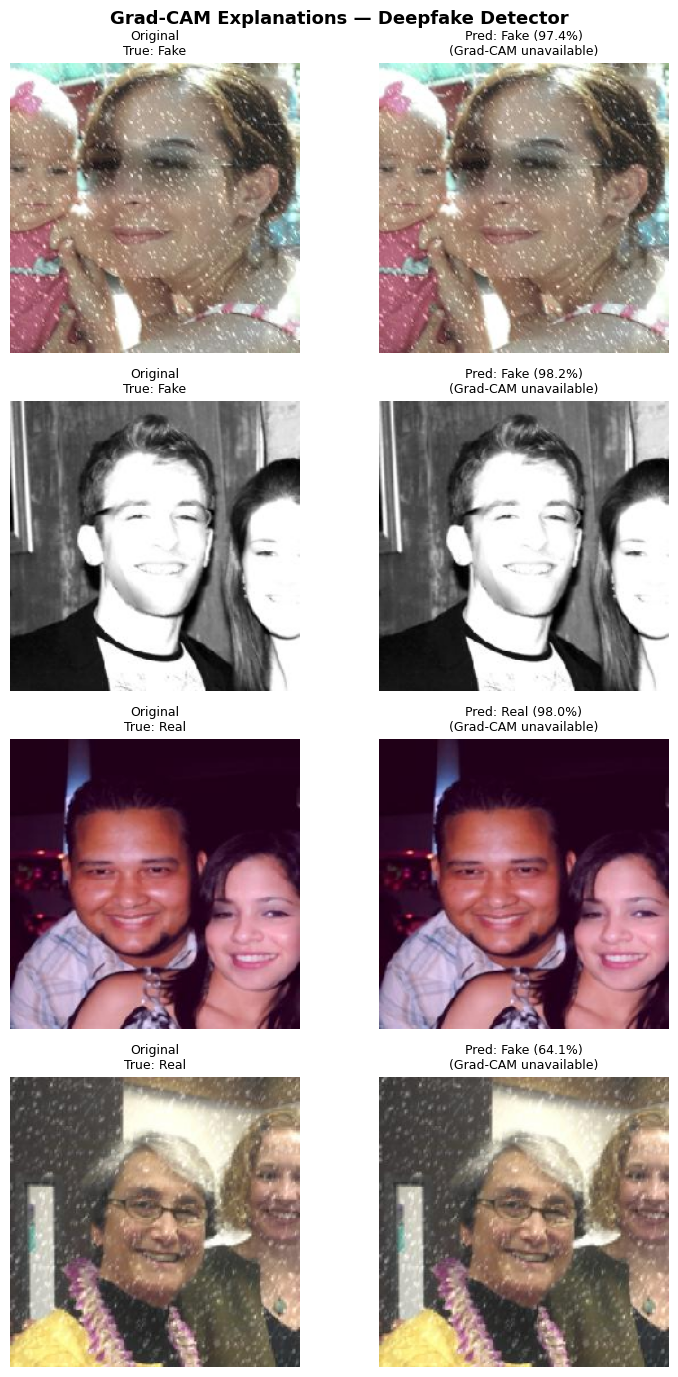

Saved: fig_gradcam.png


In [ ]:

# Grad-CAM Visualization 

import cv2

def get_gradcam_heatmap(model, img_array, last_conv_layer_name="top_conv"):
    """
    Generates Grad-CAM heatmap for the given image.
    Uses the last conv layer of EfficientNetB4 backbone.
    """
    grad_model = keras.Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_out, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, 0]

    grads    = tape.gradient(class_channel, conv_out)
    pooled   = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap  = conv_out @ pooled[..., tf.newaxis]
    heatmap  = tf.squeeze(heatmap).numpy()
    heatmap  = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-8)
    return heatmap


def overlay_gradcam(img_path, model, ax_orig, ax_cam, threshold=0.5):
    from tensorflow.keras.preprocessing import image as kimage
    img  = kimage.load_img(img_path, target_size=CFG["img_size"])
    arr  = kimage.img_to_array(img)
    inp  = keras.applications.efficientnet.preprocess_input(arr.copy())
    inp  = np.expand_dims(inp, 0)

    prob  = float(model.predict(inp, verbose=0)[0][0])
    label = IDX2CLS[int(prob > threshold)]
    conf  = prob if int(prob > threshold) == 1 else 1 - prob

    try:
        heatmap = get_gradcam_heatmap(model, inp)
        heatmap_resized = cv2.resize(heatmap, CFG["img_size"])
        heatmap_colored = cv2.applyColorMap(
            (heatmap_resized * 255).astype(np.uint8), cv2.COLORMAP_JET
        )
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
        overlay = (np.array(img) * 0.55 + heatmap_colored * 0.45).astype(np.uint8)
        ax_cam.imshow(overlay)
        ax_cam.set_title(f"Grad-CAM\n{label} ({conf:.1%})", fontsize=9)
    except Exception:
        ax_cam.imshow(img)
        ax_cam.set_title(f"Pred: {label} ({conf:.1%})\n(Grad-CAM unavailable)", fontsize=9)

    ax_orig.imshow(img)
    ax_orig.set_title(f"Original\nTrue: {os.path.basename(os.path.dirname(img_path))}", fontsize=9)
    ax_orig.axis("off")
    ax_cam.axis("off")
    return label, prob


# ---- Sample 4 images (2 real, 2 fake) ----
cls_dirs = list(test_gen.class_indices.keys())
sample_paths = []
for cls in cls_dirs[:2]:  # real and fake
    folder = os.path.join(TEST_PATH, cls)
    imgs   = [f for f in os.listdir(folder) if f.lower().endswith((".jpg",".jpeg",".png"))]
    sample_paths += [os.path.join(folder, random.choice(imgs)) for _ in range(2)]

n_samples = len(sample_paths)
fig, axes = plt.subplots(n_samples, 2, figsize=(8, n_samples * 3.5))
fig.suptitle("Grad-CAM Explanations — Deepfake Detector", fontsize=13, fontweight="bold")

for i, img_path in enumerate(sample_paths):
    overlay_gradcam(img_path, best_model, axes[i][0], axes[i][1])

plt.tight_layout()
plt.savefig(os.path.join(CFG["out_dir"], "fig_gradcam.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig_gradcam.png")


Actual class : Real


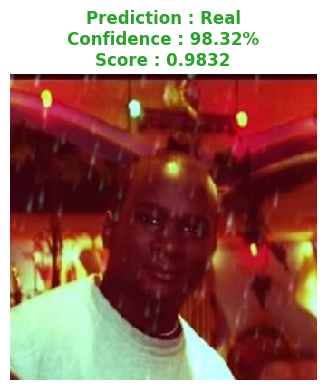

Predicted    : Real | Confidence: 98.32%


In [ ]:
# Single Image Prediction 

from tensorflow.keras.preprocessing import image as kimage

def predict_image(img_path: str, model, threshold: float = opt_threshold) -> dict:
    img  = kimage.load_img(img_path, target_size=CFG["img_size"])
    arr  = kimage.img_to_array(img)
    inp  = keras.applications.efficientnet.preprocess_input(arr.copy())
    inp  = np.expand_dims(inp, 0)
    prob = float(model.predict(inp, verbose=0)[0][0])

    pred_idx   = int(prob > threshold)
    pred_label = IDX2CLS[pred_idx]
    confidence = prob if pred_idx == 1 else 1 - prob

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    color = "#d62728" if pred_label.lower() == "fake" else "#2ca02c"
    plt.title(f"Prediction : {pred_label}\nConfidence : {confidence:.2%}\nScore : {prob:.4f}",
              color=color, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return {"prediction": pred_label, "score": prob, "confidence": confidence}

# Demo
cls      = random.choice(list(test_gen.class_indices.keys()))
folder   = os.path.join(TEST_PATH, cls)
img_file = random.choice([f for f in os.listdir(folder)
                           if f.lower().endswith((".jpg",".jpeg",".png"))])
img_path = os.path.join(folder, img_file)

print(f"\nActual class : {cls}")
result = predict_image(img_path, best_model)
print(f"Predicted    : {result['prediction']} | Confidence: {result['confidence']:.2%}")


In [ ]:
#Summary Table (Print & Save for Paper)


print("  FINAL RESULTS SUMMARY  ")
rows = [
    ("Accuracy",       f"{acc*100:.2f}%"),
    ("Precision",      f"{prec*100:.2f}%"),
    ("Recall",         f"{rec*100:.2f}%"),
    ("Specificity",    f"{spec*100:.2f}%"),
    ("F1 Score",       f"{f1*100:.2f}%"),
    ("ROC-AUC",        f"{auc:.4f}"),
    ("PR-AUC",         f"{pr_auc:.4f}"),
    ("Optimal τ",      f"{opt_threshold:.4f}"),
    ("Model",          "EfficientNetB4 + Self-Attention"),
    ("Backbone Params",f"{total_params:,}"),
]
for name, val in rows:
    print(f"  {name:<20} {val}")
print("="*65)

# Save results to text file for easy reference
results_path = os.path.join(CFG["out_dir"], "results_summary.txt")
with open(results_path, "w") as f:
    f.write("DEEPFAKE DETECTION — RESULTS SUMMARY\n")
    f.write("="*50 + "\n")
    for name, val in rows:
        f.write(f"{name:<20}: {val}\n")
print(f"Results saved → {results_path}")



  FINAL RESULTS SUMMARY  
  Accuracy             84.22%
  Precision            92.69%
  Recall               74.04%
  Specificity          94.25%
  F1 Score             82.33%
  ROC-AUC              0.9253
  PR-AUC               0.9367
  Optimal τ            0.1296
  Model                EfficientNetB4 + Self-Attention
  Backbone Params      20,512,096
Results saved → /kaggle/working/results_summary.txt
